# Carregar as bibliotecas

In [1]:
import numpy as np
from skimage import io, data, filters, util, color, transform, exposure, morphology, feature
from scipy import ndimage, stats, fft
import matplotlib.pyplot as plt
from skimage.util import img_as_float, img_as_uint, img_as_ubyte

In [2]:
def show(img_list, caption_list, Axis=False, rescale = True):
    n = len(img_list)
    f, ax = plt.subplots(1,n, figsize=(10+5*(n-1),10))
    for i in range(n):
        if rescale:
            ax[i].imshow(img_list[i], cmap='gray')
        else:
            ax[i].imshow(img_list[i], cmap='gray', vmin=0, vmax=255)
        ax[i].set_title(caption_list[i])
        if not Axis:
            ax[i].set_axis_off()

In [3]:
def gridFourier(M, N):
    u = np.arange(0, M)
    v = np.arange(0, N)

    u = u - np.floor(M/2)
    v = v - np.floor(N/2)
    U, V = np.meshgrid(u, v)
    return U, V

In [4]:
def mapping(img):
    nimg = util.img_as_float(img)
    mmin = np.min(nimg)
    nimg = nimg - mmin
    mmax = np.max(nimg)
    return (nimg/mmax)*255

In [5]:
def log_imshow(img):
    return np.log( np.abs(img)+1 )

In [6]:
def passa_freq(img, mask):
    height, width = img.shape[:2]
    fimg = fft.fftshift( fft.fft2(img) )
    fimg = fimg * mask
    nimg = fft.ifft2(fimg)
    nimg = np.abs(nimg)
    return nimg, fimg

# Questão 1

<p align="justify">
Dada a seguinte imagem, eliminar o ruído produzido pelo ruído periódico. Na figura abaixo é mostrado a imagem ruidosa e seu respectivo espectro de Fourier. Pode-se observar que existem dois pares de "spikes" (assinalados com a seta vermelha e amarela). Os ``spikes'' estão localizados nas coordenadas (36,10) e (72,-24). Utilize um filtro Notch Butterworth para apagar os coeficiente ao redor dos spikes.
</p>

<p align="justify">

</p>

<table><tr>
<td> <img src="https://drive.google.com/uc?id=10O_eu9WzBZzpTR1ila3R8wZ0SDzkM2kF" alt="Drawing"  width="300"/> </td>
<td> <img src="https://drive.google.com/uc?id=1cWr8WzFa6lHwyCFK1_iDOsrKu-lGqM1I" alt="Drawing"  width="300"/> </td>

</tr></table>



<p align"justify">
Filtro notch: São filtros capazes de rejeitar uma faixa bastante estreita de frequências. Sua utilização é recomendada quando o sinal a ser atenuado é bem definido. Pelo fato de atuar em faixas reduzidas de frequências, filtros notch interferem pouco na qualidade do sinal. A figura a continuação mostra apenas um par de regiões sendo retirado.
</p>

<img src="https://drive.google.com/uc?id=1L4J9Y6yFpKMebHyceWb1cy7j6CWljixO" alt="Drawing"  width="300"/>

<p align"justify">
A área em torno da frequência de corte escolhida ($D_0$) que pode ser retirada é definida na construção do filtro. Seja $D_0$ a frequência de corte do filtro notch centrado em ($u_0, v_0$) e, por simetria ($-u_0, -v_0$):

$$D_1(u,v) = \sqrt{(u - M/2 - u_0)^2 + (v - N/2 - v_0)^2}$$

$$D_2(u,v) = \sqrt{(u - M/2 + u_0)^2 + (v - N/2 + v_0)^2}$$

$$H(u,v) = \frac{1}{1 + \left(\frac{D_0^2}{D_1(u,v)D_2(u,v)}\right)^{2n}}$$

Crie um filtro notch para remover a ruído periódico
</p>


In [11]:
img = io.imread('https://drive.google.com/uc?id=10O_eu9WzBZzpTR1ila3R8wZ0SDzkM2kF')

In [12]:
def mask_butterworth_notch(width, height, d0, n, u, v):
  U, V = gridFourier(width, height)
  D1 = np.sqrt((U - u) ** 2 + (V - v) ** 2)
  D2 = np.sqrt((U + u) ** 2 + (V + v) ** 2)
  H = 1 / (1 + ((d0 ** 2) / (D1 * D2)) ** (2 * n))
  return H

/tmp/ipykernel_37756/925622942.py:5: RuntimeWarning: divide by zero encountered in divide
  H = 1 / (1 + ((d0 ** 2) / (D1 * D2)) ** (2 * n))


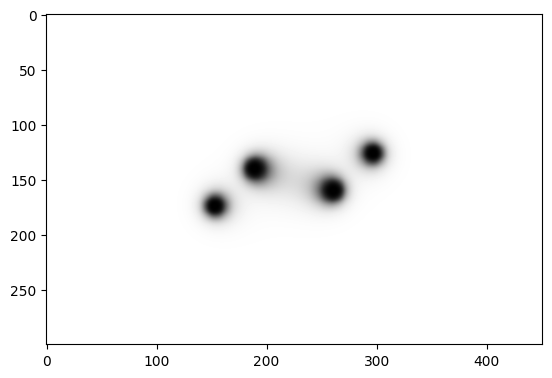

In [13]:
lin, col = img.shape[:2]
HN1 = mask_butterworth_notch(col, lin, 30, 2, 36, 10)
HN2 = mask_butterworth_notch(col, lin, 40, 2, 72,-24)
HN = HN1*HN2
plt.imshow(HN, cmap='gray',vmin=0, vmax=1)

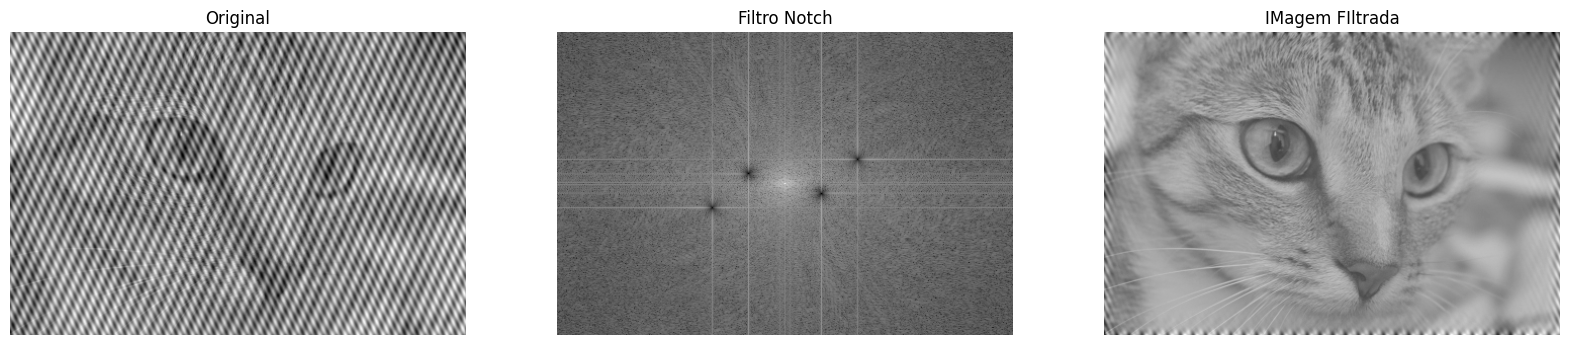

In [14]:
nimg, fimg = passa_freq(img, HN)
show([img, np.log(np.abs(fimg)+1), nimg], ['Original','Filtro Notch', 'IMagem FIltrada'])

# Questão 2
<p align="justify">
Repita o processo de remoção do ruído periódico da questão anterior utilizando os seguintes filtro passa-bandas: ideal, Butterworth e Gaussiano.
<p>

<p align="justify">
Filtro Ideal:
$$H(u,v) = \begin{cases}
0 & \text{se } D_0-\frac{W}{2} \leq D \leq D_0 + \frac{W}{2}\\
1 & \text{otherwise}
\end{cases} $$
<p>

<p align="justify">
Filtro Butterworth:
$$H(u,v) = \frac{1}{1 + \left(\frac{D.W}{D^2 - D_0^2}\right)^{2n}}$$
<p>

<p align="justify">
Filtro Gaussiano:
$$H(u,v) = 1 - e^{-  \left(\frac{D^2 - D_0^2}{D.W} \right)^2 }$$
<p>

In [19]:
def mask_ideal_band(width, height, d0, W):
    U, V = gridFourier(width, height)

    D = np.sqrt(U**2 + V**2)

    H = np.ones((height, width))

    # Primeiro anel
    band1 = (D >= d0 - W/2) & (D <= d0 + W/2)

    # Segundo anel com raio dobrado
    d1 = 2 * d0
    band2 = (D >= d1 - W/2) & (D <= d1 + W/2)

    # Rejeita os dois
    H[band1 | band2] = 0.0
    return H

In [20]:
def mask_butterworth_band(width, height, d0, n, W):
    U, V = gridFourier(width, height)
    D = np.sqrt(U**2 + V**2)
    eps = 1e-6

    # --- Primeiro Anel (Raio d0) ---
    denominador1 = D**2 - d0**2
    denominador1 = np.where(denominador1 == 0, eps, denominador1)
    H1 = 1 / (1 + ((D * W) / denominador1)**(2 * n))

    # --- Segundo Anel (Raio d1 = 2 * d0) ---
    d1 = 2 * d0
    denominador2 = D**2 - d1**2
    denominador2 = np.where(denominador2 == 0, eps, denominador2)
    H2 = 1 / (1 + ((D * W) / denominador2)**(2 * n))

    # Multiplica os dois filtros para obter os dois anéis no mesmo espectro
    H = H1 * H2
    return H

In [21]:
def mask_gaussian_band(width, height, d0, W):
    U, V = gridFourier(width, height)

    D = np.sqrt(U**2 + V**2)

    eps = 1e-6

    H1 = 1 - np.exp(-((D**2 - d0**2 + eps) / (D * W + eps))**2)

    d1 = 2 * d0

    H2 = 1 - np.exp(-((D**2 - d1**2 + eps) / (D * W + eps))**2)

    H = H1 * H2

    return H

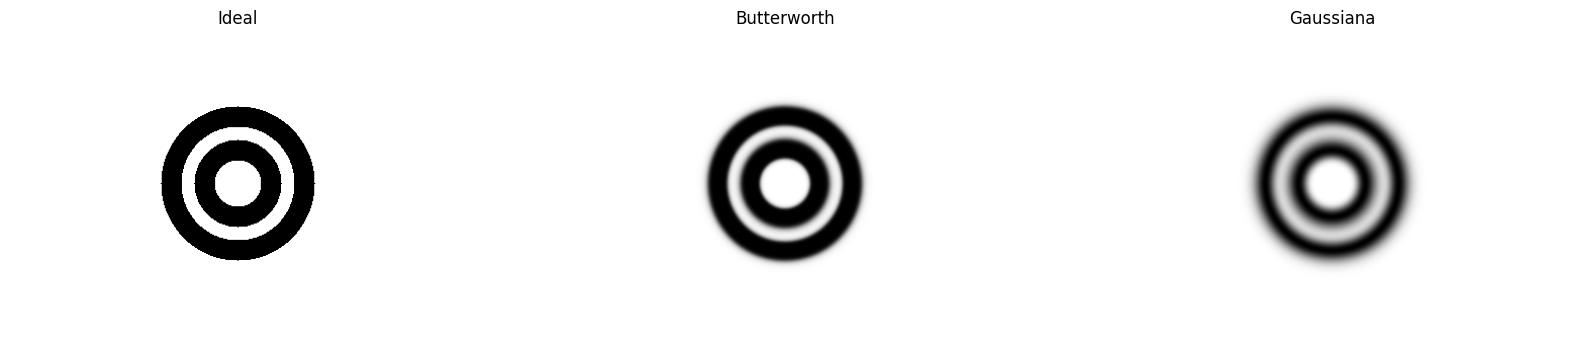

In [22]:
width, height = img.shape[1], img.shape[0]   # ou defina manualmente
d0 = 33
w = 20
n = 4
HI = mask_ideal_band(width, height, d0, w)
HB = mask_butterworth_band(width, height, d0, n, w)
HG = mask_gaussian_band(width, height, d0, w)
show([HI, HB, HG], ['Ideal','Butterworth', 'Gaussiana'])

297 126


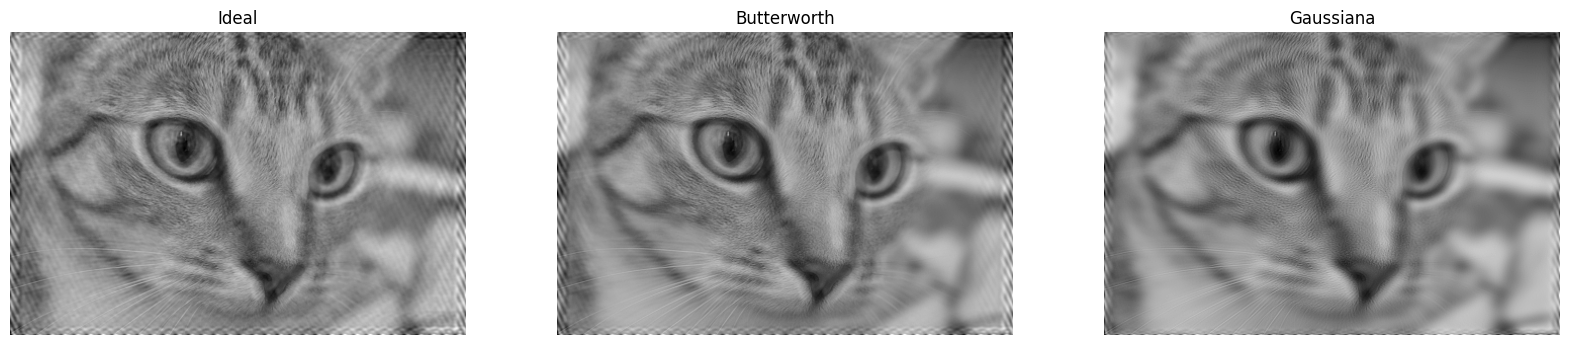

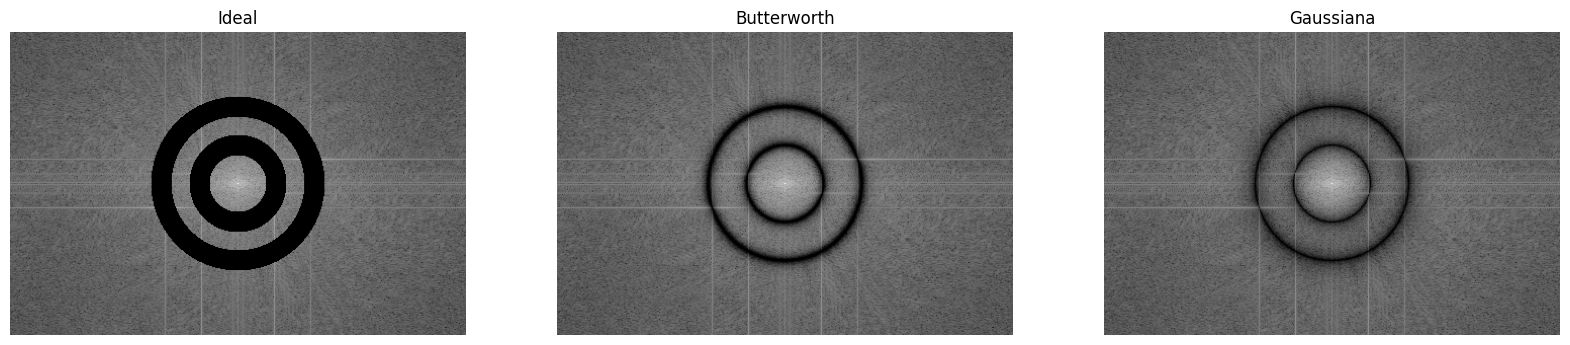

In [24]:
F = np.fft.fftshift(np.fft.fft2(img))

mag = np.log(np.abs(F) + 1)

# ignora o centro
cy, cx = mag.shape[0]//2, mag.shape[1]//2
mag[cy-10:cy+10, cx-10:cx+10] = 0

# pega o pico mais forte
y, x = np.unravel_index(np.argmax(mag), mag.shape)

print(x, y)

raio = np.sqrt((x-cx)**2 + (y-cy)**2)

raio1 = raio/2
raio2 = raio
HI = mask_ideal_band(col, lin, raio1, 20)

HB = mask_butterworth_band(col, lin, raio1, 2, 20)

HG = mask_gaussian_band(col, lin, raio1, 45)
nimgI, fimgI = passa_freq(img, HI)
nimgB, fimgB = passa_freq(img, HB)
nimgG, fimgG = passa_freq(img, HG)

show([nimgI, nimgB, nimgG], ['Ideal','Butterworth', 'Gaussiana'])
show([np.log(np.abs(fimgI)+1), np.log(np.abs(fimgB)+1), np.log(np.abs(fimgG)+1)], ['Ideal','Butterworth', 'Gaussiana'])

## Questao 3
<p> Uma outra forma de realçar as bordas de uma imagem é através do Laplaciano. A continuação é definido o $\textit{unsharp masking}$ baseado no Laplaciano

$$f(x,y) + \alpha(\bigtriangledown^2f(x,y))$$
onde $\bigtriangledown^2f(x,y)$ é o Laplaciano da imagem $f(x,y)$ e $\alpha$ é um fator de escala. Implementar a função $\textit{unsharp masking}$
</p>

In [17]:
def highboost(img, alpha=-3):
  mask = np.array([[0,1,0],[1,-4,1],[0,1,0]])
  fimg = util.img_as_float(img, force_copy=True)
  laplacian = ndimage.convolve(fimg, mask)
  nimg2 = fimg + alpha*laplacian
  nimg2 = np.clip(nimg2, 0, 1)
  return nimg2

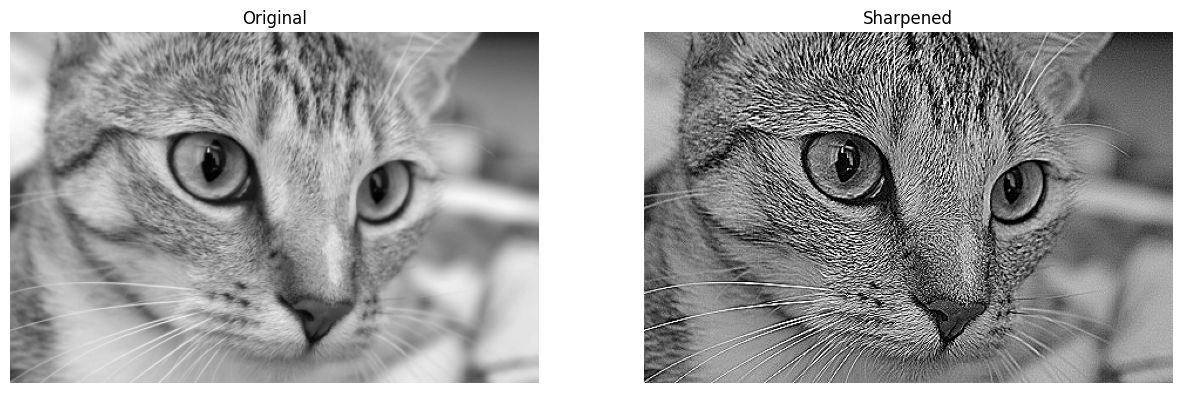

In [18]:
img = color.rgb2gray(data.chelsea())
nimg2 = highboost(img, alpha=-3)
show([img,nimg2 ],['Original', 'Sharpened'])

## Questao 4

<p>
Crie uma nova versão da seguinte imagem aplicando a função <i>modifica</i>
</p>
<img src="https://drive.google.com/uc?id=1lWiT-Wz7ZFhWRf-u__aqxwzaho6AtLG8" alt="Drawing"  width="300"/>
<p>
Logo, binarize a nova imagem gerada usando um filtro adaptativo.
</p>

In [101]:
def modifica2(img):
  fimg = util.img_as_float(img, force_copy=True)
  lin, col = fimg.shape[:2]
  x = np.ones((lin,1)) @ np.arange(col).reshape(1,col)
  nimg = fimg * ( x/2 + 50 ) + (1-fimg) * x/2
  return mapping(nimg)

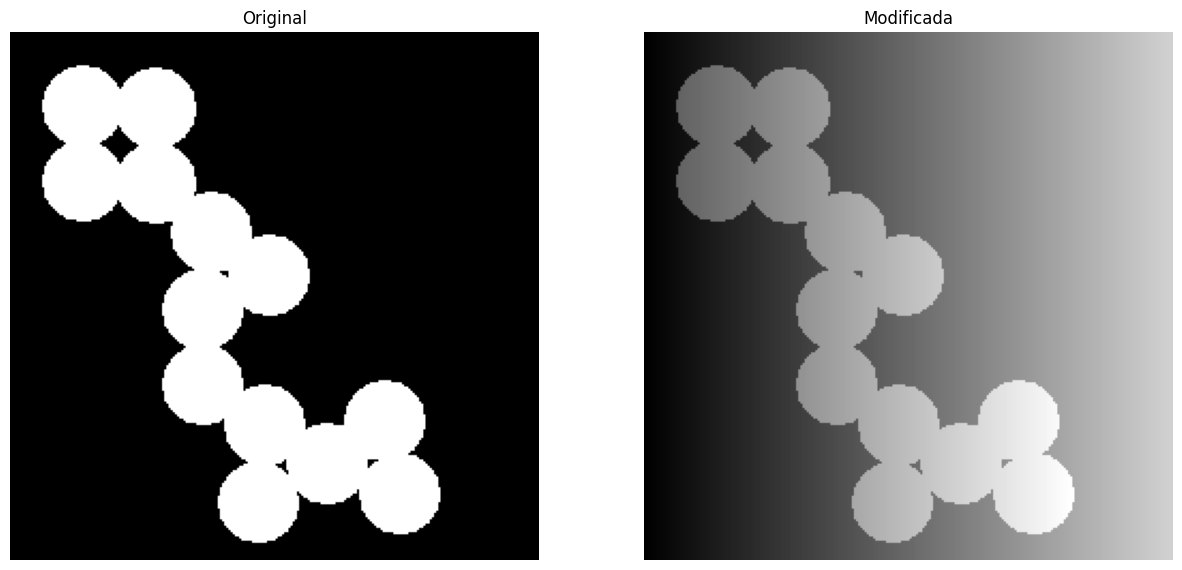

In [102]:
img = io.imread("https://drive.google.com/uc?id=1lWiT-Wz7ZFhWRf-u__aqxwzaho6AtLG8", as_gray=True)
nimg = modifica2(img)
show([img, nimg], ['Original', 'Modificada'])

### Implemente o filtro adaptativo de segmentação e compare o resultado com um filtro global

In [105]:
from skimage.util import view_as_blocks

def segmentacao_adaptativa(img, bloco_h, bloco_w):
    img_u = img_as_ubyte(img / np.max(img))
    
    lin, col = img_u.shape
    
    h = int(np.ceil(lin / bloco_h))
    w = int(np.ceil(col / bloco_w))
    
    lin_pad = h * bloco_h
    col_pad = w * bloco_w
    img_pad = np.pad(img_u, ((0, lin_pad - lin), (0, col_pad - col)), mode='edge')
    
    blocos = view_as_blocks(img_pad, block_shape=(h, w))
    
    out = np.zeros_like(img_pad, dtype=bool)
    
    # Limiar global como fallback para blocos sem variação
    thresh_global = filters.threshold_otsu(img_u)
    
    for i in range(bloco_h):
        for j in range(bloco_w):
            bloco = blocos[i, j]
            # Se o bloco tiver baixa variância, usa o limiar global
            if bloco.std() < 5:
                out[i*h:(i+1)*h, j*w:(j+1)*w] = bloco > thresh_global
            else:
                thresh_local = filters.threshold_otsu(bloco)
                out[i*h:(i+1)*h, j*w:(j+1)*w] = bloco > thresh_local
    
    return out[:lin, :col]

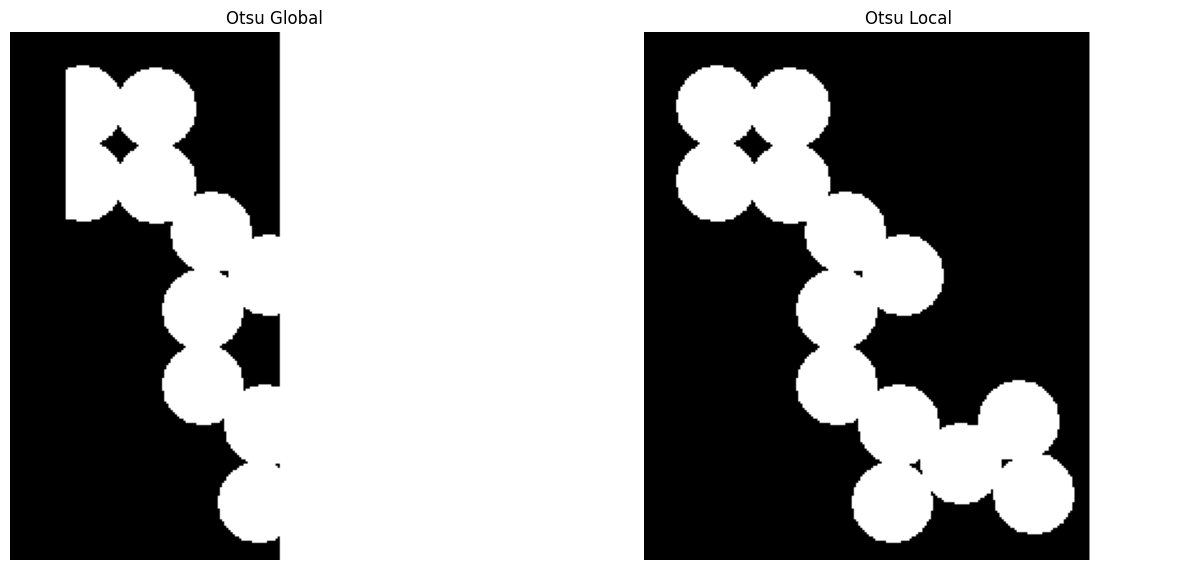

In [106]:
nimg2 = segmentacao_adaptativa(nimg, 1,20)
thresh = filters.threshold_otsu(nimg)
nimg3 = nimg > thresh
show([nimg3, nimg2], ['Otsu Global', 'Otsu Local'])

## Questão 5

<p>O método de <b>Richardson–Lucy</b> (RL) é um algoritmo iterativo de restauração de imagens utilizado para desfazer o efeito de borramento causado por uma função de espalhamento pontual (<i>Point Spread Function</i> – PSF). O modelo de formação da imagem borrada $B(x,y)$ é:
$$B(x,y)=(I∗P)(x,y)+n(x,y),$$
onde
<ul>
<li>$I(x,y)$ é a imagem original desconhecida,</li>
<li>$P(x,y)$ é a PSF do sistema,</li>
<li>* representa convolução,</li>
<li>$n$ é o ruído (assumido Poisson no modelo RL).</li>
</ul>

O algoritmo de Richardson–Lucy atualiza a estimativa $I_k(x,y)$ da imagem original utilizando:
$$I_{k+1}(x,y)=I_k(x,y)⋅\left[\frac{B(x,y)}{(I_k*P)(x,y)}*P^{rot}(x,y)\right]$$
onde $𝑃^{rot}$ é o kernel $P$ rotacionado em $180°$ (necessário porque a segunda convolução corresponde a uma correlação cruzada).</p>


###Tarefa

<p>Implemente o algoritmo de Richardson–Lucy para restaurar uma imagem borrada, seguindo os seguintes passos:
<ol>
<li>Carregar a imagem de entrada (imagem borrada) e a PSF utilizada no processo.</li>
<li>Inicializar a estimativa $I_0$ como sendo a própria imagem borrada ou uma matriz uniforme.</li>
<li>Implementar o ciclo iterativo do algoritmo:</li>
  <ul>
  <li>Convoluir a imagem estimada com o PSF.</li>
  <li>Dividir a imagem borrada pelo resultado da convolução.</li>
  <li>Convolver o resultado dessa divisão com o PSF rotacionado.</li>
  <li>Atualizar a estimativa multiplicativamente.</li>
  </ul>
<li>Repetir o processo por um número K de iterações informado pelo usuário.</li>
<li>Exibir a imagem restaurada após K iterações.</li>
<li>Comparar visualmente a imagem borrada com a imagem restaurada.</li>
</ol>

https://stackoverflow.com/questions/9854312/how-does-richardson-lucy-algorithm-work-code-example

In [54]:
#from scipy.signal import convolve2d
def richardson_lucy(image, psf, iterations=20):
    """
    Implementação manual do algoritmo de deconvolução Richardson–Lucy.
    """
    psf_rot = np.rot90(psf, 2)
    
    estimate = image.copy()
    
    for _ in range(iterations):
        convolved = ndimage.convolve(estimate, psf, mode='reflect')
        
        ratio = image / (convolved + 1e-10)
        
        correction = ndimage.convolve(ratio, psf_rot, mode='reflect')
        
        estimate = estimate * correction
    
    return estimate

In [55]:
def matlab_style_gauss2D(shape=(3,3),sigma=0.5):
    """
    2D gaussian mask - should give the same result as MATLAB's
    fspecial('gaussian',[shape],[sigma])
    https://stackoverflow.com/questions/17190649/how-to-obtain-a-gaussian-filter-in-python
    """
    m,n = [(ss-1.)/2. for ss in shape]
    y,x = np.ogrid[-m:m+1,-n:n+1]

    h = np.exp( -(x*x + y*y) / (2.*sigma*sigma) )
    h[ h < np.finfo(h.dtype).eps*h.max() ] = 0
    sumh = h.sum()
    if sumh != 0:
        h /= sumh
    return h

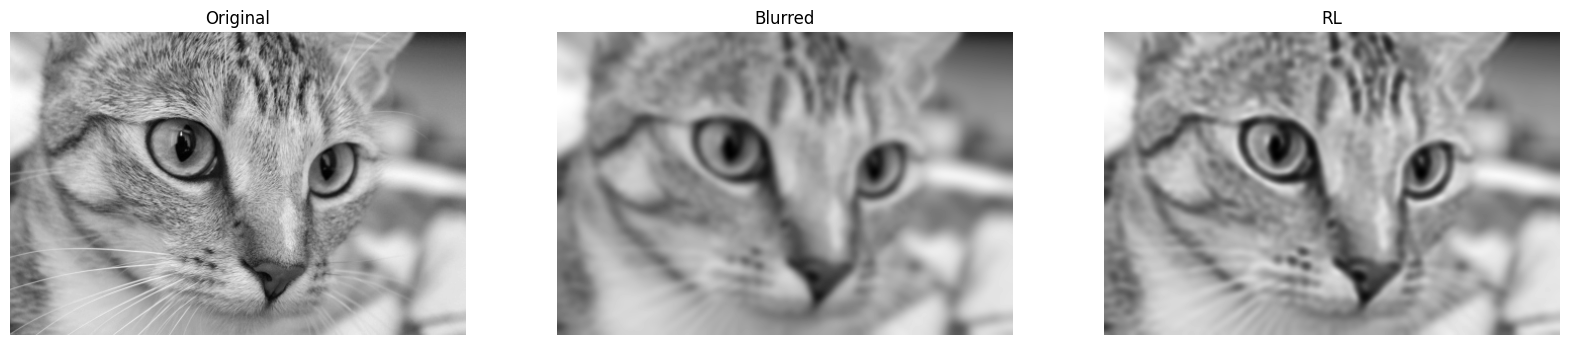

In [56]:
psf =  matlab_style_gauss2D(shape=(15,15), sigma=3)
img = util.img_as_float(color.rgb2gray(data.chelsea()))
blurred = ndimage.convolve(img, psf, mode='reflect')
rl_manual = richardson_lucy(blurred, psf, iterations=20)
show([img, blurred, rl_manual], ['Original', 'Blurred', 'RL'])



## Questao 6

<p>Encontre as bordas de uma imagem binaria através destas três técnicas de morfologia matemética</p>

<ol>
<li>Bordas internas: $A-(A \ominus B)$</li>
<li>Bordas externas: $(A \oplus B) - A$</li>
<li>Gradiente morfológico: $(A \oplus B) - (A \ominus B)$</li>
</ol>

A diferença lógica é definida da seguinte forma: $A - B = A \textrm{ and } (not B)$

In [57]:
img = io.imread('https://drive.google.com/uc?id=1iB1pIbjzvA0pDxS0UqXsDEeZNe0wyrdT', as_gray=True)

In [58]:
def logical_difference(A, B):
    return A & (~B)

/tmp/ipykernel_24156/2151774708.py:1: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  B = morphology.square(3)


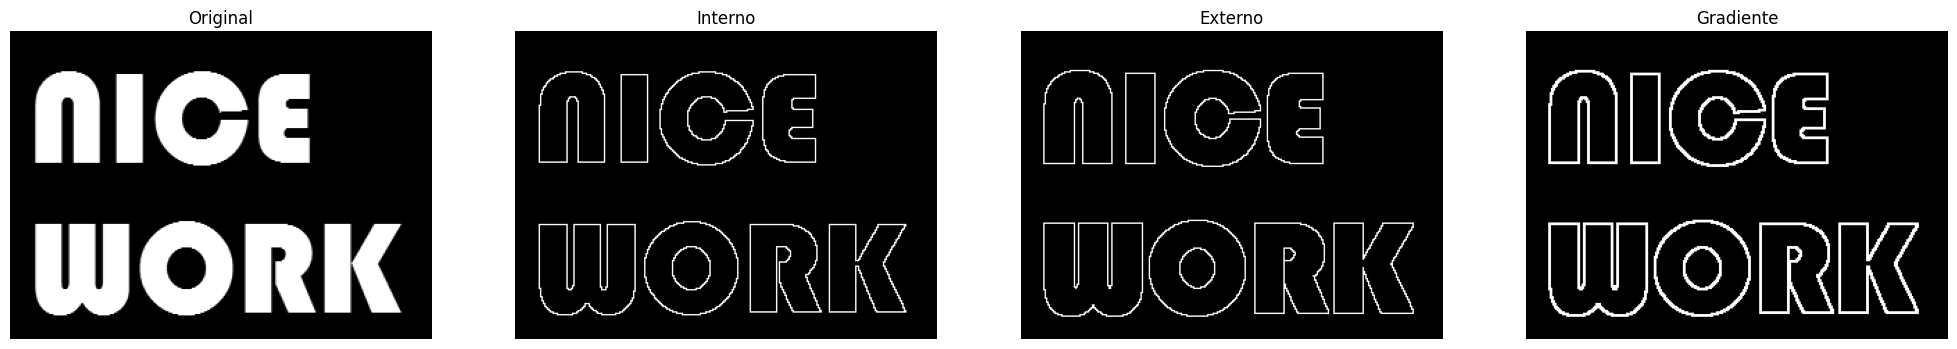

In [61]:
B = morphology.square(3)

edge_inner = logical_difference(img > 0.5, morphology.binary_erosion(img > 0.5, B))
edge_outer = logical_difference(morphology.binary_dilation(img > 0.5, B), img > 0.5)
edge_grad  = logical_difference(morphology.binary_dilation(img > 0.5, B), morphology.binary_erosion(img > 0.5, B))

show([img, edge_inner, edge_outer, edge_grad],['Original', 'Interno', 'Externo', 'Gradiente'])

## Questão 7

<p>Ao realizar a convolução de uma imagem com um filtro utilizando a Transformada Discreta de Fourier (DFT), ocorre um problema conhecido como wrap-around error (ou “erro de contorno circular”). Esse erro surge porque a DFT implementa naturalmente uma convolução circular, enquanto o objetivo em processamento de imagens é realizar uma convolução linear, onde a borda da imagem é estendida com zeros.

Neste exercício, você deverá implementar uma convolução 2D linear usando FFT, evitando o wrap-around error através de zero-padding mínimo, e garantindo que o tamanho final da imagem expandida seja uma potência de 2, para reduzir o custo computacional da FFT.

A convolução circular realizada pela FFT assume que a imagem “se repete infinitamente” nas bordas. Assim, durante a reconstrução, valores que deveriam “sair da borda da imagem” retornam e aparecem no lado oposto, produzindo artefatos visuais.

Para obter o resultado da convolução linear verdadeira, deve-se expandir tanto a imagem quanto o filtro com zeros antes de aplicar a FFT.

Se a imagem tem tamanho $M \times N$ e uma máscara tem tamanho $m \times n$, então o tamanho mínimo necessário para evitar o wrap-around é:
$$P_{min} \geq M+m−1, \hspace{1cm} Q_{min} \geq N+n−1$$

Expandir (zero-pad) a imagem para tamanho $P \times Q$:
$$P = 2^{log_2(P_{min})}, \hspace{1cm} Q=2^{log_2(Q_{min})}$$

</p><p>Garantir que $P$ e $Q$ sejam potências de 2 maximiza o desempenho computacional da FFT, pois os algoritmos de FFT são otimizados para estas dimensões.</p><p>Além do zero-padding, é necessário um cuidado especial com o <strong>posicionamento do kernel</strong>. A FFT espera que a origem (ponto (0,0)) do sinal esteja no canto superior esquerdo da matriz. No entanto, para que a multiplicação no domínio da frequência represente corretamente a convolução linear, o <strong>centro do kernel deve estar na origem</strong>. Por esta razão, aplica-se um deslocamento circular (roll) para centralizar o kernel fisicamente na matriz, seguido de <strong>fftshift</strong> para reposicionar a origem da FFT no canto. A imagem, por outro lado, <strong>não deve ser deslocada</strong> - ela permanece no canto superior esquerdo da matriz com zero-padding.</p>

$Convolução Linear = IFFT( FFT(imagem) * FFTSHIFT(FFT(kernel\_shifted)) )$

<b>Passos para Implementação</b>

<p>Sua função convFreq_padded(img, mask) deve executar a seguinte sequência de operações:
<ol>
<li>Passo 1: Conversão a imagem para float
<li>Passo 2: Extrair as dimensões da imagem: $M \times N$ e  as dimensões da máscara: $m \times n$
<li>Passo 3: Calcular tamanhos mínimos para evitar wrap-around na convolução linear:
$$P_{min} = M + m - 1$$
$$ Q_{min} = N + n - 1$$
Estes são os tamanhos mínimos para evitar wrap-around na convolução linear
<li>Passo 4: Calcular as potências de 2, maior ou igual, mais próximas do valor. Usar a função auxiliar next_power_of_two(valor)
<li>Passo 5: Zero-padding da imagem. Criar matriz img_padded de zeros com tamanho $P \times Q$ e posicionar a imagem original no canto superior esquerdo.
<li>Passo 6: Preparação da máscara (kernel)
  <ul>
  <li>Criar matriz kernel_padded de zeros com tamanho $P \times Q$
  <li>Posicionar a máscara no canto superior esquerdo
  </ul>
<li>Passo 7: Deslocamento físico do kernel para o centro
  <ul>
  <li>Calcular deslocamento vertical: $shift_y = P // 2 - m // 2 + 1$
  <li>Calcular deslocamento horizontal: $shift_x = Q // 2 - n // 2 + 1$
  <li>Aplicar np.roll para mover o kernel ao centro da matriz:
  </ul>
<li>Passo 8: Aplicar fftshift no  fft do kernel. Importante: fftshift é aplicado apenas no kernel, não na imagem
<li>Passo 9: Aplicar FFT 2D da imagem
<li>Passo 10: Multiplicação no domínio da frequência. Multiplicar elemento a elemento: $G_{freq} = F * H$
<li>Passo 11: Transformada inversa. Extrair apenas a parte real
<li>Passo 12: Recortar o resultado. Retornar apenas a região de tamanho $M \times N$ (mesmo tamanho da imagem original)
</ol>
</p>

In [67]:
# ---------------------------------------------------------------
# 1. Função para calcular a menor potência de 2 >= valor
# ---------------------------------------------------------------
def next_power_of_two(value):
    return 1 << (value - 1).bit_length()

In [69]:
def convFreq_padded(img, mask):
    # Passo 1: Conversão para float
    img_f = img_as_float(img, force_copy=True)

    # Passo 2: Dimensões da imagem e da máscara
    M, N = img_f.shape[:2]
    m, n = mask.shape[:2]

    # Passo 3: Tamanhos mínimos para evitar wrap-around
    P_min = M + m - 1
    Q_min = N + n - 1

    # Passo 4: Próxima potência de 2
    P = next_power_of_two(P_min)
    Q = next_power_of_two(Q_min)

    # Passo 5: Zero-padding da imagem
    img_padded = np.zeros((P, Q))
    img_padded[:M, :N] = img_f

    # Passo 6: Zero-padding da máscara
    kernel_padded = np.zeros((P, Q))
    kernel_padded[:m, :n] = mask

    # Passo 7: Deslocamento físico do kernel para a origem
    shift_y = -(m // 2)
    shift_x = -(n // 2)
    kernel_padded = np.roll(kernel_padded, shift_y, axis=0)
    kernel_padded = np.roll(kernel_padded, shift_x, axis=1)

    # Passo 8: FFT do kernel (sem fftshift)
    H = fft.fft2(kernel_padded)

    # Passo 9: FFT 2D da imagem
    F = fft.fft2(img_padded)

    # Passo 10: Multiplicação no domínio da frequência
    G_freq = F * H

    # Passo 11: Transformada inversa (parte real)
    result = np.real(fft.ifft2(G_freq))

    # Passo 12: Recortar para o tamanho original M x N
    return result[:M, :N]

In [70]:
def convFreq(img, mask):
    img_f = img_as_float(img, force_copy=True)
    lin, col = img.shape[:2]
    maskF = np.zeros( (lin, col) )
    maskF[:mask.shape[0], :mask.shape[1]] = mask
    nimg = fft.fft2(img) * fft.fft2(maskF)
    nimg = np.abs( fft.ifft2(nimg) )
    return nimg

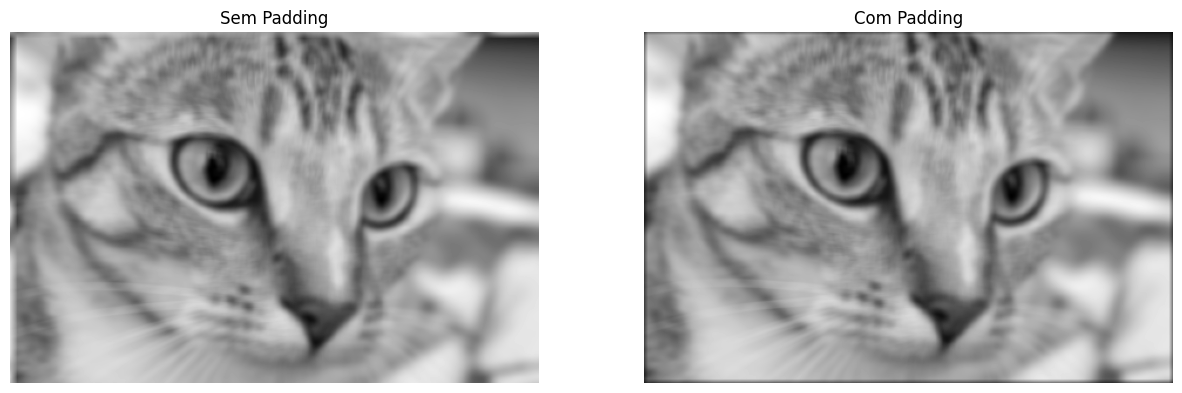

In [71]:
img = data.chelsea()
img = color.rgb2gray(img)
mask = np.ones( (7,7) ) / 49
nimg = convFreq(img, mask)
nimg2 = convFreq_padded(img, mask)
show([nimg, nimg2],['Sem Padding','Com Padding'])